# Lecture 7, A lumped hydrological model

Lectures 4 to 6 wrote an ordinary differential equation for the **energy** stored at a
point on the Earth and stepped it forward in time. This lecture does exactly the same
thing for the **water** stored in a river catchment. The state variable changes from a
temperature to a set of water storages, but the machinery &mdash; a balance equation,
a few parameters, a time-stepping loop, a `class` that holds the state &mdash; is the
one you already know.

A model that treats the whole catchment as a single unit, with no spatial detail, is
called a **lumped** model. In the language of the rest of the course it is a
*zero-dimensional* model of the water cycle, and it is the first entry in Module 2's
hierarchy of hydrological models, below the semi-distributed and distributed models
(SWAT, VIC, HEC-HMS) that resolve space.


In [1]:
# --- Google Colab setup ---
import sys
if "google.colab" in sys.modules:
    %pip install -q numpy pandas matplotlib scipy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## 1) The catchment water balance

Write $S(t)$ for the total water stored in a catchment &mdash; in the soil, in shallow
groundwater, in channels. Over any interval it changes by what comes in minus what
goes out:

$$\frac{dS}{dt} = P - E - Q,$$

where $P$ is precipitation, $E$ is actual evapotranspiration, and $Q$ is streamflow at
the outlet. This is the hydrological twin of the energy balance $C\,dT/dt = \text{ASR}
- \text{OLR} + \dots$ of Lecture 4.

Everything is expressed as a **depth over the catchment area**, in millimetres per day:
a discharge of $Q$ m³ s⁻¹ from a catchment of area $A$ m² is
$Q \times 86400 / A \times 1000$ mm day⁻¹. Working in mm keeps $P$, $E$ and $Q$ on the
same footing and makes the balance easy to check.

The lumped assumption is that one value of $P$, one soil moisture, one groundwater
level and so on describe the entire catchment. That is clearly wrong in detail, but for
predicting the streamflow *at the outlet* it is often good enough, and it keeps the
model small enough to understand and to calibrate.


## 2) A model structure

$P$, $E$ and $Q$ do not act on a single store. Rain first wets the **soil**; only when
the soil is wet does much of it become runoff; and that runoff reaches the outlet by
two routes &mdash; a **fast** near-surface path and a **slow** groundwater path that
sustains flow between storms. The smallest structure that captures this has three
kinds of store:

- a **soil-moisture store** $S$ of capacity $S_{max}$;
- a **fast pathway**, two identical linear reservoirs in series (a short Nash cascade),
  which delays and smooths the storm response;
- a **slow pathway**, one linear reservoir, which produces baseflow.

Each day, given $P$ and potential evapotranspiration $E_p$:

$$\text{soil wetness}\quad s = S/S_{max}$$

$$\text{runoff generation}\quad R = P\,s^{\beta}
\qquad\text{(more rain runs off as the soil fills)}$$

$$\text{actual ET}\quad E = E_p\,s\,(2 - s)
\qquad\text{(rises fast when wet, tails off when dry)}$$

$$S \leftarrow S + P - R - E \qquad\text{(any excess above } S_{max}\text{ spills to } R)$$

$$\text{percolation to groundwater}\quad L = k_{perc}\,S\,s^{3}$$

The fast reservoirs receive $R$, the slow reservoir receives $L$, and each linear
reservoir releases a fixed fraction of its content per day: $q = k\,\text{(store)}$.
Total streamflow is the sum of the fast and slow outflows.

The five parameters are

| symbol | meaning | units |
|---|---|---|
| $S_{max}$ | soil-moisture capacity | mm |
| $\beta$ | runoff-generation nonlinearity | &ndash; |
| $k_{perc}$ | percolation rate, soil &rarr; groundwater | day⁻¹ |
| $k_f$ | fast-reservoir recession | day⁻¹ |
| $k_s$ | slow-reservoir recession | day⁻¹ |


In [2]:
class Catchment:
    """A lumped daily rainfall-runoff model.

    One soil-moisture store feeds a fast pathway (two linear reservoirs in series)
    and a slow pathway (one linear reservoir).
    """

    def __init__(self, smax=250.0, beta=2.5, kperc=0.05, kf=0.4, ks=0.015):
        self.smax = smax        # soil-moisture capacity [mm]
        self.beta = beta        # runoff-generation nonlinearity [-]
        self.kperc = kperc      # percolation rate [1/day]
        self.kf = kf            # fast-reservoir recession [1/day]
        self.ks = ks            # slow-reservoir recession [1/day]

    def run(self, prcp, pet, s0=0.5, return_stores=False):
        smax, beta, kperc = self.smax, self.beta, self.kperc
        kf, ks = self.kf, self.ks
        prcp = np.asarray(prcp, float)
        pet = np.asarray(pet, float)

        S = s0 * smax           # soil moisture
        F1 = F2 = R = 0.0       # fast cascade (2) and slow reservoir
        n = len(prcp)
        q = np.empty(n)
        total_store = np.empty(n)

        for t in range(n):
            p, ep = prcp[t], pet[t]
            s = min(max(S / smax, 0.0), 1.0)

            runoff = p * s ** beta                 # saturation-excess generation
            aet = ep * s * (2.0 - s)               # actual evapotranspiration
            S = S + p - runoff - aet
            if S > smax:                           # spill excess
                runoff += S - smax
                S = smax
            if S < 0.0:                            # cannot dry below zero
                aet += S
                S = 0.0

            perc = kperc * S * s ** 3              # drainage to groundwater
            S -= perc

            F1 += runoff
            R += perc
            o1 = kf * F1; F1 -= o1                 # linear-reservoir outflows
            F2 += o1
            o2 = kf * F2; F2 -= o2
            qs = ks * R;  R -= qs

            q[t] = o2 + qs
            total_store[t] = S + F1 + F2 + R

        return (q, total_store) if return_stores else q


## 3) The data

We use one catchment: the **Chattooga River near Clayton, Georgia** (USGS gauge
02177000), a forested, humid, near-natural basin of about 540 km² in the southern
Appalachians &mdash; one of the reference catchments in the CAMELS large-sample
dataset. The daily record in `data/chattooga_daily.csv` runs 1991&ndash;2015 and holds

- `prcp_mm` &mdash; precipitation (Daymet v4)
- `tmean_c` &mdash; mean air temperature (Daymet v4)
- `pet_mm` &mdash; potential evapotranspiration, Oudin (2005) estimate from temperature
- `q_mm` &mdash; observed streamflow (USGS), converted to mm day⁻¹

Sources and licences are listed at the end of the notebook.


In [3]:
df = pd.read_csv("data/chattooga_daily.csv", comment="#",
                 parse_dates=["date"], index_col="date")
print(df.describe().round(2))

annual = df.resample("YS").sum(min_count=350)
print("\nlong-term annual means [mm/yr]:")
print(f"  P   = {annual['prcp_mm'].mean():6.0f}")
print(f"  PET = {annual['pet_mm'].mean():6.0f}")
print(f"  Q   = {annual['q_mm'].mean():6.0f}")
print(f"  runoff ratio Q/P = {annual['q_mm'].mean()/annual['prcp_mm'].mean():.2f}")


       prcp_mm  tmean_c   pet_mm     q_mm
count  9131.00  9131.00  9131.00  9131.00
mean      4.77    14.94     2.67     2.88
std      11.00     7.84     1.57     2.59
min       0.00    -9.38     0.00     0.31
25%       0.00     8.54     1.18     1.40
50%       0.00    15.53     2.53     2.31
75%       4.58    22.12     4.18     3.62
max     164.37    29.28     5.80    84.42

long-term annual means [mm/yr]:
  P   =   1742
  PET =    974
  Q   =   1051
  runoff ratio Q/P = 0.60


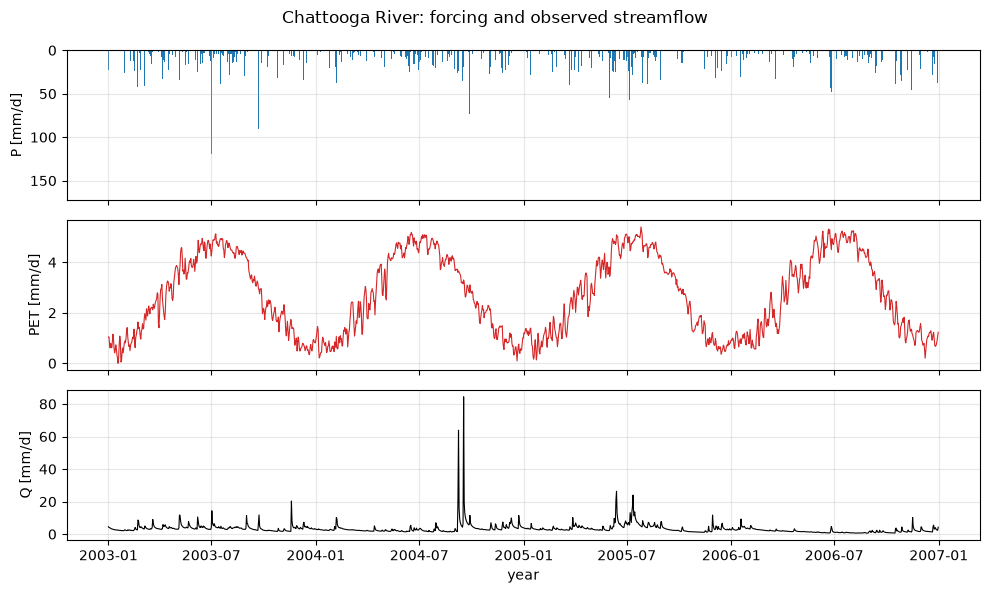

In [4]:
fig, ax = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
sl = slice("2003", "2006")
ax[0].bar(df.loc[sl].index, df.loc[sl, "prcp_mm"], width=1, color="tab:blue")
ax[0].set_ylabel("P [mm/d]"); ax[0].invert_yaxis()
ax[1].plot(df.loc[sl].index, df.loc[sl, "pet_mm"], color="tab:red", lw=0.8)
ax[1].set_ylabel("PET [mm/d]")
ax[2].plot(df.loc[sl].index, df.loc[sl, "q_mm"], color="black", lw=0.8)
ax[2].set_ylabel("Q [mm/d]"); ax[2].set_xlabel("year")
for a in ax:
    a.grid(alpha=0.3)
fig.suptitle("Chattooga River: forcing and observed streamflow")
fig.tight_layout()


The streamflow record has the shape every hydrologist recognises: sharp peaks a day or
two after heavy rain, riding on a smooth baseflow that rises through winter and recedes
through the dry late summer. A model that reproduces this needs *both* a fast and a
slow pathway, which is why the structure above has two.

A compact summary of the flow regime is the **flow-duration curve** &mdash; streamflow
sorted from largest to smallest against the fraction of time it is exceeded.


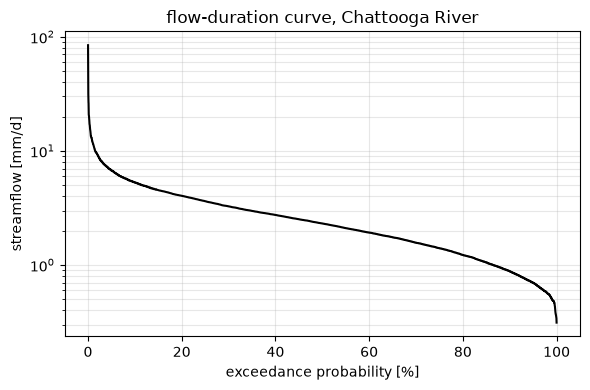

In [5]:
q = df["q_mm"].dropna().sort_values(ascending=False).values
p_exc = np.arange(1, len(q) + 1) / (len(q) + 1)

fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(p_exc * 100, q, color="black")
ax.set_xlabel("exceedance probability [%]")
ax.set_ylabel("streamflow [mm/d]")
ax.set_title("flow-duration curve, Chattooga River")
ax.grid(alpha=0.3, which="both")
fig.tight_layout()


## 4) A first simulation

Pick a plausible parameter set by hand, force the model with the observed $P$ and
$E_p$, and compare its streamflow with the gauge. We discard the first two years as
**warm-up**: the model starts from a guessed soil moisture and needs time to forget it.


Nash-Sutcliffe efficiency (1993-2015): 0.64


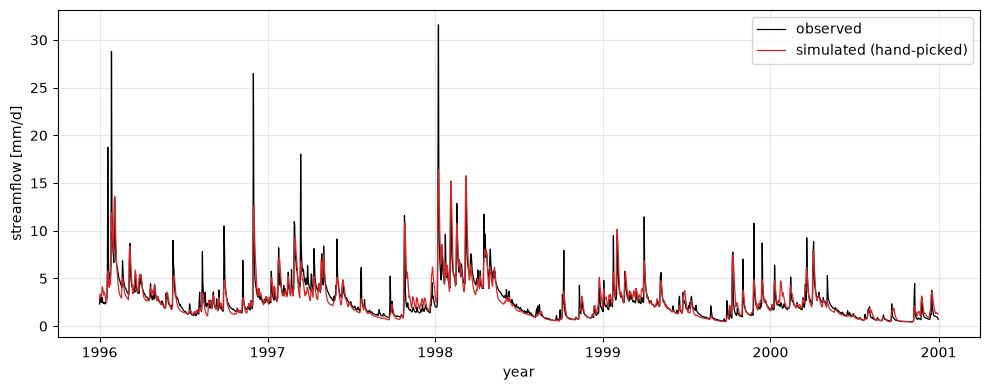

In [6]:
model = Catchment(smax=250.0, beta=2.5, kperc=0.05, kf=0.40, ks=0.015)
qsim = model.run(df["prcp_mm"].values, df["pet_mm"].values, s0=0.5)
df["qsim_hand"] = qsim

show = slice("1996", "2000")
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df.loc[show].index, df.loc[show, "q_mm"], color="black", lw=0.9, label="observed")
ax.plot(df.loc[show].index, df.loc[show, "qsim_hand"], color="tab:red", lw=0.9,
        label="simulated (hand-picked)")
ax.set_ylabel("streamflow [mm/d]"); ax.set_xlabel("year")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()

def nse(obs, sim):
    m = np.isfinite(obs) & np.isfinite(sim)
    o, s = obs[m], sim[m]
    return 1.0 - np.sum((s - o) ** 2) / np.sum((o - o.mean()) ** 2)

ev = df.loc["1993":]                      # drop warm-up
print(f"Nash-Sutcliffe efficiency (1993-2015): {nse(ev['q_mm'].values, ev['qsim_hand'].values):.2f}")


The hand-picked run already gets the *timing* of the storm peaks and the general level
of baseflow, but it misses peak magnitudes and the shape of the recessions. Lecture 8
is about finding the parameter values that fit best, and about being honest regarding
how good "best" really is.


## 5) What each parameter does

The quickest way to build intuition is to vary one parameter at a time around the
hand-picked set and watch the hydrograph respond.


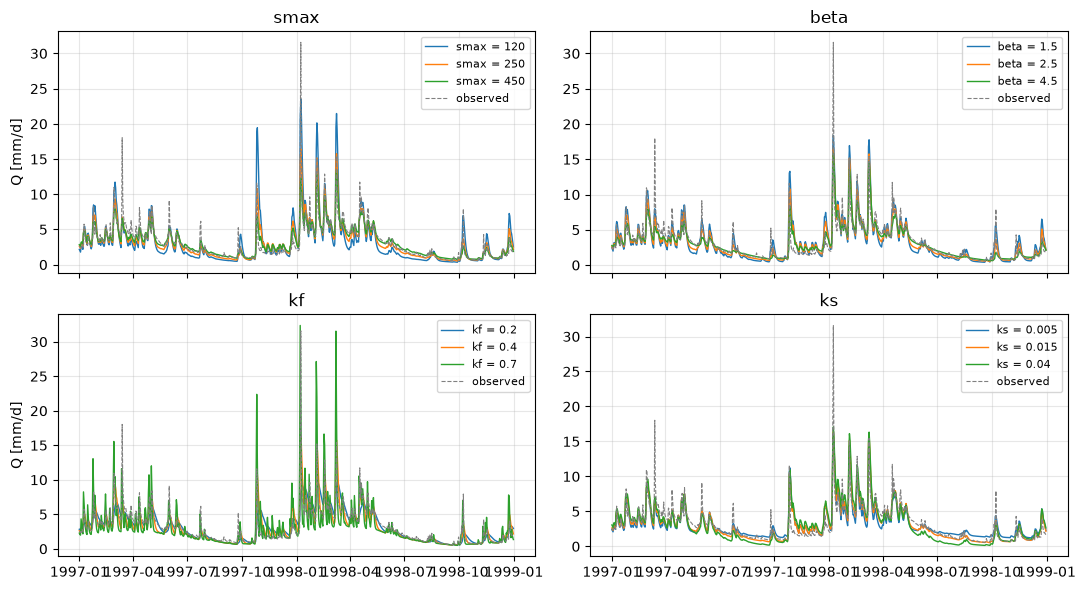

In [7]:
base = dict(smax=250.0, beta=2.5, kperc=0.05, kf=0.40, ks=0.015)
sweeps = {
    "smax":  [120, 250, 450],
    "beta":  [1.5, 2.5, 4.5],
    "kf":    [0.20, 0.40, 0.70],
    "ks":    [0.005, 0.015, 0.04],
}
win = slice("1997", "1998")
P = df["prcp_mm"].values; Ep = df["pet_mm"].values
t = df.index

fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex=True)
for ax, (name, values) in zip(axes.flat, sweeps.items()):
    for v in values:
        pars = dict(base); pars[name] = v
        qs = pd.Series(Catchment(**pars).run(P, Ep), index=t)
        ax.plot(qs.loc[win].index, qs.loc[win], lw=1.0, label=f"{name} = {v}")
    ax.plot(df.loc[win].index, df.loc[win, "q_mm"], color="0.5", lw=0.8, ls="--",
            label="observed")
    ax.set_title(name); ax.legend(fontsize=8); ax.grid(alpha=0.3)
axes[1, 0].set_ylabel("Q [mm/d]"); axes[0, 0].set_ylabel("Q [mm/d]")
fig.tight_layout()


- **$S_{max}$** sets how much rain the soil can soak up before it spills: a small
  $S_{max}$ makes the catchment flashy, a large one damps every event.
- **$\beta$** controls how sharply runoff switches on as the soil wets &mdash; large
  $\beta$ means almost nothing runs off until the soil is nearly full, then it all does.
- **$k_f$** is the fast recession: large $k_f$ empties the fast reservoirs quickly and
  gives sharp, short peaks.
- **$k_s$** is the slow recession: it sets how fast baseflow declines through the dry
  season, and barely touches the peaks.

Each parameter has a distinct fingerprint on the hydrograph. That is what makes
calibration possible &mdash; and, where two parameters have *similar* fingerprints,
what makes it hard (Lecture 8).


## 6) Does the water balance close?

A model can produce a plausible-looking hydrograph and still leak water. Over a long
run, with the change in storage $\Delta S$ accounted for, precipitation must equal the
sum of actual evapotranspiration, streamflow, and the storage change.


In [8]:
q_sim, store = Catchment(**base).run(P, Ep, s0=0.5, return_stores=True)
# recompute actual ET for the same run
S = 0.5 * base["smax"]; aet_series = np.empty(len(P))
for i in range(len(P)):
    s = min(max(S / base["smax"], 0.0), 1.0)
    runoff = P[i] * s ** base["beta"]
    aet = Ep[i] * s * (2 - s)
    S = S + P[i] - runoff - aet
    if S > base["smax"]:
        S = base["smax"]
    if S < 0:
        aet += S; S = 0.0
    S -= base["kperc"] * S * s ** 3
    aet_series[i] = aet

P_tot = P.sum()
E_tot = aet_series.sum()
Q_tot = q_sim.sum()
dS = store[-1] - store[0]
print(f"P            = {P_tot:9.0f} mm")
print(f"E (actual)   = {E_tot:9.0f} mm")
print(f"Q            = {Q_tot:9.0f} mm")
print(f"delta storage= {dS:9.0f} mm")
print(f"P - (E + Q + dS) = {P_tot - (E_tot + Q_tot + dS):.2f} mm  (should be ~0)")


P            =     43551 mm
E (actual)   =     17694 mm
Q            =     25556 mm
delta storage=       303 mm
P - (E + Q + dS) = -0.56 mm  (should be ~0)


The residual is a rounding-level number: the model conserves water, which every
hydrological model must. It is worth adding this check to any model you build.


## 7) Exercises

```{admonition} Exercise 1 &mdash; a snow store
:class: tip
Add a snow module ahead of the soil store: accumulate precipitation as snow when
`tmean_c` is below 0 °C, and melt it at a rate `ddf * max(tmean_c, 0)` mm day⁻¹
(degree-day factor `ddf` ≈ 3). Feed rain + melt into the soil store instead of raw
precipitation. Pick a colder CAMELS catchment and compare the hydrograph with and
without the snow module. This is the catchment-scale version of the snow&ndash;albedo
discussion in Lectures 1 and 5.
```

```{admonition} Exercise 2 &mdash; a monthly model
:class: tip
Aggregate the forcing to monthly totals and run the model at a monthly step. Which
parameters still matter, and which become irrelevant? Relate your answer to the
timescale-separation argument of Lecture 2.
```

```{admonition} Exercise 3 &mdash; another catchment
:class: tip
Download daily streamflow for a different USGS gauge (or an Indian catchment, if you
have the data) and Daymet or IMD forcing, build the same CSV, and run the model. Does
the same parameter set work? What does that tell you about transferring parameters
between catchments?
```


## Sources

**Data.** Streamflow: U.S. Geological Survey, National Water Information System, gauge
02177000 (public domain). Precipitation and temperature: Daymet v4, ORNL DAAC (public
domain; Thornton et al. 2022, doi:10.3334/ORNLDAAC/2129). Potential evapotranspiration:
Oudin, L. et al. (2005), *Journal of Hydrology* 303, 290&ndash;306. The catchment is
part of the CAMELS dataset (Newman et al. 2015; Addor et al. 2017).

**Tools.** This notebook builds the model from scratch for teaching. For real work,
established Python packages implement calibrated, tested versions of models like GR4J,
HBV and HYMOD &mdash; for example [LuMod](https://gitlab.com/Zaul_AE/lumod) (S.
Arciniega-Esparza) and [SPOTPY](https://spotpy.readthedocs.io/) (Houska et al.) for
calibration and uncertainty analysis.

**Licensing.** Original teaching material for this course; text under CC BY-SA 4.0, code additionally under the MIT License, consistent with the rest of the book. See [CREDITS.md](https://github.com/drvivekhydro/hydroclimatology/blob/main/CREDITS.md).
